In [2]:
# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import sys
import random
import subprocess
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)

Устанавливаем пакет: faiss-cpu
Устанавливаем пакет: sentence-transformers
NumPy: 2.2.4
Pandas: 2.2.3
FAISS available: True


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


In [4]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "sql_01",
        "title": "Что такое реляционная база данных",
        "text": (
            "Реляционная база данных хранит информацию в связанных таблицах. Каждая таблица состоит из строк (записей) "
            "и столбцов (полей с определённым типом данных). Связи между таблицами реализуются через внешние ключи. "
            "Для управления реляционными базами данных используется язык SQL."
        ),
    },
    {
        "doc_id": "sql_02",
        "title": "SELECT и фильтрация данных",
        "text": (
            "Оператор SELECT используется для выборки данных из таблицы. Базовый синтаксис: SELECT column1, column2 FROM table_name. "
            "Для фильтрации строк применяется WHERE с условиями: =, <>, >, <, LIKE, IN, BETWEEN. "
            "Пример: SELECT * FROM users WHERE age >= 18 AND city = 'Москва'."
        ),
    },
    {
        "doc_id": "sql_03",
        "title": "Сортировка и ограничение результатов",
        "text": (
            "ORDER BY сортирует результаты запроса по одному или нескольким столбцам. По умолчанию — по возрастанию (ASC), "
            "для убывания используется DESC. LIMIT ограничивает количество возвращаемых строк. "
            "Практический пример: SELECT name, salary FROM employees ORDER BY salary DESC LIMIT 10 — топ-10 сотрудников по зарплате."
        ),
    },
    {
        "doc_id": "sql_04",
        "title": "Агрегатные функции",
        "text": (
            "Агрегатные функции выполняют вычисления на наборе строк и возвращают одно значение. Основные функции: "
            "COUNT(*) — количество строк, SUM() — сумма, AVG() — среднее, MIN() и MAX() — минимум и максимум. "
            "Обычно используются с GROUP BY для группировки данных по какому-то признаку."
        ),
    },
    {
        "doc_id": "sql_05",
        "title": "GROUP BY и HAVING",
        "text": (
            "GROUP BY группирует строки с одинаковыми значениями в указанных столбцах, после чего можно применить агрегацию. "
            "HAVING фильтрует группы — это аналог WHERE, но для сгруппированных данных. "
            "Пример: SELECT department, AVG(salary) FROM employees GROUP BY department HAVING AVG(salary) > 50000."
        ),
    },
    {
        "doc_id": "sql_06",
        "title": "Объединение таблиц JOIN",
        "text": (
            "JOIN объединяет данные из двух или более таблиц по связанным столбцам. Основные типы: "
            "INNER JOIN — только совпадающие записи, LEFT JOIN — все записи из левой таблицы и совпадающие из правой, "
            "RIGHT JOIN и FULL OUTER JOIN. Чаще всего используют INNER JOIN и LEFT JOIN для анализа связанных данных."
        ),
    },
    {
        "doc_id": "sql_07",
        "title": "Подзапросы",
        "text": (
            "Подзапрос — это запрос внутри другого запроса. Может использоваться в WHERE, FROM или SELECT. "
            "Пример: SELECT name FROM employees WHERE department_id IN (SELECT id FROM departments WHERE location = 'Москва'). "
            "Подзапросы удобны, но иногда их можно заменить на JOIN для лучшей производительности."
        ),
    },
    {
        "doc_id": "sql_08",
        "title": "Индексы и производительность",
        "text": (
            "Индекс — это структура данных, ускоряющая поиск строк по определённым столбцам. Чаще всего используют B-деревья. "
            "Создаётся индекс командой CREATE INDEX idx_name ON table_name(column). Индексы ускоряют SELECT, но замедляют INSERT/UPDATE/DELETE. "
            "Важно не злоупотреблять и индексировать только те столбцы, по которым реально часто ищут или фильтруют."
        ),
    },
    {
        "doc_id": "sql_09",
        "title": "Транзакции и ACID",
        "text": (
            "Транзакция — группа операций, которая выполняется как единое целое. ACID — четыре свойства транзакций: "
            "Атомарность (всё или ничего), Согласованность (целостность данных после транзакции), "
            "Изоляция (параллельные транзакции не мешают друг другу), Долговечность (сохранность после сбоя). "
            "Команды: BEGIN, COMMIT, ROLLBACK."
        ),
    },
    {
        "doc_id": "sql_10",
        "title": "Нормализация баз данных",
        "text": (
            "Нормализация — процесс организации данных для устранения избыточности и аномалий. Основные нормальные формы: "
            "1НФ — атомарные значения в столбцах, 2НФ — нет частичных зависимостей от составного ключа, "
            "3НФ — нет транзитивных зависимостей. На практике часто останавливаются на 3НФ, но в аналитических системах "
            "допустима денормализация для ускорения чтения."
        ),
    },
    {
    "doc_id": "sql_11",
    "title": "Оконные функции",
    "text": (
        "Оконные функции (window functions) выполняют вычисления по набору строк, связанных с текущей строкой, но без свёртки в одну строку. "
        "Синтаксис: функция OVER (PARTITION BY столбец ORDER BY столбец). Примеры: ROW_NUMBER() — нумерация строк, "
        "LAG() — значение из предыдущей строки, RANK() — ранжирование с пропусками. Оконные функции незаменимы для расчёта "
        "скользящих средних, кумулятивных сумм и сравнения значения строки с другими строками группы."
    ),
},
]

docs_df_sql = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df_sql))
display(docs_df_sql[["doc_id", "title"]])

Размер корпуса: 11


,doc_id,title
0,sql_01,Что такое реляционная база данных
1,sql_02,SELECT и фильтрация данных
2,sql_03,Сортировка и ограничение результатов
3,sql_04,Агрегатные функции
4,sql_05,GROUP BY и HAVING
5,sql_06,Объединение таблиц JOIN
6,sql_07,Подзапросы
7,sql_08,Индексы и производительность
8,sql_09,Транзакции и ACID
9,sql_10,Нормализация баз данных


In [5]:
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\ML\pytorch_env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo-PC\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [6]:
def chunk_text(text: str, chunk_size: int = 22, overlap: int = 5) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=22, overlap=5)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 31


,doc_id,title,chunk_id,chunk_text,n_words
0,sql_01,Что такое реляционная база данных,0,Реляционная база данных хранит информацию в св...,22
1,sql_01,Что такое реляционная база данных,1,с определённым типом данных). Связи между табл...,19
2,sql_02,SELECT и фильтрация данных,0,Оператор SELECT используется для выборки данны...,22
3,sql_02,SELECT и фильтрация данных,1,"строк применяется WHERE с условиями: =, <>, >,...",22
4,sql_02,SELECT и фильтрация данных,2,WHERE age >= 18 AND city = 'Москва'.,8
5,sql_03,Сортировка и ограничение результатов,0,ORDER BY сортирует результаты запроса по одном...,22
6,sql_03,Сортировка и ограничение результатов,1,убывания используется DESC. LIMIT ограничивает...,22
7,sql_03,Сортировка и ограничение результатов,2,salary DESC LIMIT 10 — топ-10 сотрудников по з...,9
8,sql_04,Агрегатные функции,0,Агрегатные функции выполняют вычисления на наб...,22
9,sql_04,Агрегатные функции,1,"SUM() — сумма, AVG() — среднее, MIN() и MAX() ...",22


In [7]:
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (31, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


In [8]:
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [9]:
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


# Проверяем FAISS-поиск на первом запросе.
# Результаты должны совпасть с ручным расчётом из секции 6:
# тот же top-k, те же фрагменты, те же оценки сходства.
faiss_query = "Почему для similarity search нужен индекс по векторам?"
faiss_results_df = search_similar_chunks(faiss_query, top_k=5)

display(Markdown(f"**Запрос:** {faiss_query}"))
display(faiss_results_df)

**Запрос:** Почему для similarity search нужен индекс по векторам?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,sql_08,Индексы и производительность,0,0.4488,"Индекс — это структура данных, ускоряющая поис..."
1,2,sql_08,Индексы и производительность,2,0.4123,"только те столбцы, по которым реально часто ищ..."
2,3,sql_11,Оконные функции,3,0.4120,кумулятивных сумм и сравнения значения строки ...
3,4,sql_05,GROUP BY и HAVING,0,0.4108,GROUP BY группирует строки с одинаковыми значе...
4,5,sql_11,Оконные функции,2,0.3826,"— значение из предыдущей строки, RANK() — ранж..."


In [10]:
example_queries = [
    # К doc_01 (Что такое реляционная база данных)
    "Что такое реляционная база данных и как в ней связаны таблицы?",

    # К doc_02 (SELECT и фильтрация данных)
    "Как выбрать данные из таблицы и отфильтровать их по условию?",

    # К doc_03 (Сортировка и ограничение результатов)
    "Как отсортировать сотрудников по зарплате и показать только топ-10?",

    # К doc_04 (Агрегатные функции)
    "Какие агрегатные функции существуют в SQL и для чего они нужны?",

    # К doc_05 (GROUP BY и HAVING)
    "Как посчитать среднюю зарплату по отделам и отфильтровать отделы с зарплатой выше 50000?",

    # К doc_06 (Объединение таблиц JOIN)
    "Чем отличаются INNER JOIN и LEFT JOIN?",

    # К doc_07 (Подзапросы)
    "Что такое подзапрос и когда его лучше заменить на JOIN?",

    # К doc_08 (Индексы и производительность)
    "Как индексы влияют на производительность запросов?",

    # К doc_09 (Транзакции и ACID)
    "Что такое транзакция и какие свойства ACID она должна обеспечивать?",

    # К doc_10 (Нормализация баз данных)
    "Что такое нормализация и какие бывают нормальные формы?",

    # К doc_11 (Оконные функции)
    "Как с помощью оконной функции посчитать номер строки в группе?",
]

In [11]:
for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Что такое реляционная база данных и как в ней связаны таблицы?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,sql_01,Что такое реляционная база данных,0,0.8238,Реляционная база данных хранит информацию в св...
1,2,sql_01,Что такое реляционная база данных,1,0.7256,с определённым типом данных). Связи между табл...
2,3,sql_04,Агрегатные функции,2,0.6385,BY для группировки данных по какому-то признаку.


### Запрос: `Как выбрать данные из таблицы и отфильтровать их по условию?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,sql_02,SELECT и фильтрация данных,0,0.6455,Оператор SELECT используется для выборки данны...
1,2,sql_01,Что такое реляционная база данных,0,0.5945,Реляционная база данных хранит информацию в св...
2,3,sql_04,Агрегатные функции,2,0.5138,BY для группировки данных по какому-то признаку.


### Запрос: `Как отсортировать сотрудников по зарплате и показать только топ-10?`

...

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,sql_09,Транзакции и ACID,0,0.6650,"Транзакция — группа операций, которая выполняе..."
1,2,sql_09,Транзакции и ACID,1,0.3168,"ничего), Согласованность (целостность данных п..."
2,3,sql_07,Подзапросы,2,0.3109,их можно заменить на JOIN для лучшей производи...


### Запрос: `Что такое нормализация и какие бывают нормальные формы?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,sql_10,Нормализация баз данных,0,0.4377,Нормализация — процесс организации данных для ...
1,2,sql_11,Оконные функции,2,0.2422,"— значение из предыдущей строки, RANK() — ранж..."
2,3,sql_04,Агрегатные функции,0,0.2292,Агрегатные функции выполняют вычисления на наб...


### Запрос: `Как с помощью оконной функции посчитать номер строки в группе?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,sql_05,GROUP BY и HAVING,0,0.6659,GROUP BY группирует строки с одинаковыми значе...
1,2,sql_11,Оконные функции,3,0.6404,кумулятивных сумм и сравнения значения строки ...
2,3,sql_04,Агрегатные функции,2,0.5925,BY для группировки данных по какому-то признаку.


In [12]:
import os
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [13]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 28
baseline_overlap = 8

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

# Посмотрим несколько контрольных запросов вручную.
sample_queries = [
    "Объясни, что такое реляционная БД простыми словами",
    "Как написать запрос, чтобы найти всех пользователей старше 18 лет из Москвы?",
    "Как пронумеровать строки в каждой группе данных?",
]
for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 24


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,sql_01,Что такое реляционная база данных,sql_01_chunk_0,0,Реляционная база данных хранит информацию в св...
1,sql_01,Что такое реляционная база данных,sql_01_chunk_1,1,данных). Связи между таблицами реализуются чер...
2,sql_02,SELECT и фильтрация данных,sql_02_chunk_0,0,Оператор SELECT используется для выборки данны...
3,sql_02,SELECT и фильтрация данных,sql_02_chunk_1,1,"с условиями: =, <>, >, <, LIKE, IN, BETWEEN. П..."
4,sql_03,Сортировка и ограничение результатов,sql_03_chunk_0,0,ORDER BY сортирует результаты запроса по одном...


### Запрос: Объясни, что такое реляционная БД простыми словами

,rank,score,doc_id,title,chunk_text
0,1,0.405346,sql_10,Нормализация баз данных,Нормализация — процесс организации данных для ...
1,2,0.397187,sql_09,Транзакции и ACID,"Транзакция — группа операций, которая выполняе..."
2,3,0.371452,sql_11,Оконные функции,функция OVER (PARTITION BY столбец ORDER BY ст...


### Запрос: Как написать запрос, чтобы найти всех пользователей старше 18 лет из Москвы?

,rank,score,doc_id,title,chunk_text
0,1,0.668154,sql_02,SELECT и фильтрация данных,"с условиями: =, <>, >, <, LIKE, IN, BETWEEN. П..."
1,2,0.360820,sql_07,Подзапросы,department_id IN (SELECT id FROM departments W...
2,3,0.252954,sql_07,Подзапросы,Подзапрос — это запрос внутри другого запроса....


### Запрос: Как пронумеровать строки в каждой группе данных?

,rank,score,doc_id,title,chunk_text
0,1,0.700056,sql_05,GROUP BY и HAVING,GROUP BY группирует строки с одинаковыми значе...
1,2,0.560447,sql_01,Что такое реляционная база данных,Реляционная база данных хранит информацию в св...
2,3,0.542308,sql_06,Объединение таблиц JOIN,JOIN объединяет данные из двух или более табли...


In [14]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое подзапрос?",
        "relevant_doc_ids": ["sql_07"],
    },
    {
        "query_id": "q02",
        "query": "что делает ORDER BY?",
        "relevant_doc_ids": ["sql_03"],
    },
    {
        "query_id": "q03",
        "query": "Что такое нормализация баз данных?",
        "relevant_doc_ids": ["sql_10"],
    },
    {
        "query_id": "q04",
        "query": "Для чего нужен JOIN?",
        "relevant_doc_ids": ["sql_06"],
    },
    {
        "query_id": "q05",
        "query": "Что такое индекс в базе данных?",
        "relevant_doc_ids": ["sql_08"],
    },
    {
        "query_id": "q06",
        "query": "Зачем нужны транзакции?",
        "relevant_doc_ids": ["sql_09"],
    },
    {
        "query_id": "q07",
        "query": "Что делает GROUP BY?",
        "relevant_doc_ids": ["sql_05"],
    },
    {
        "query_id": "q08",
        "query": "Что такое оконные функции?",
        "relevant_doc_ids": ["sql_11"],
    },
]



In [15]:
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое подзапрос?,sql_07,"sql_07, sql_09, sql_03",1,1.0,1.0,1
1,q02,что делает ORDER BY?,sql_03,"sql_03, sql_11, sql_07",1,1.0,1.0,1
2,q03,Что такое нормализация баз данных?,sql_10,"sql_01, sql_10",1,1.0,0.5,2
3,q04,Для чего нужен JOIN?,sql_06,sql_06,1,1.0,1.0,1
4,q05,Что такое индекс в базе данных?,sql_08,"sql_08, sql_01",1,1.0,1.0,1
5,q06,Зачем нужны транзакции?,sql_09,"sql_09, sql_01",1,1.0,1.0,1
6,q07,Что делает GROUP BY?,sql_05,"sql_05, sql_06",1,1.0,1.0,1
7,q08,Что такое оконные функции?,sql_11,"sql_11, sql_04",1,1.0,1.0,1


,metric,value
0,mean_hit@3,1.0000
1,mean_recall@3,1.0000
2,mean_MRR@3,0.9375


In [16]:
chunk_configs = [
    {"chunk_size": 18, "overlap": 4},
    {"chunk_size": 28, "overlap": 8},
    {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 15},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,60,15,12,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.9375
1,28,8,24,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.9375
2,40,10,19,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.8750
3,18,4,37,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.8750


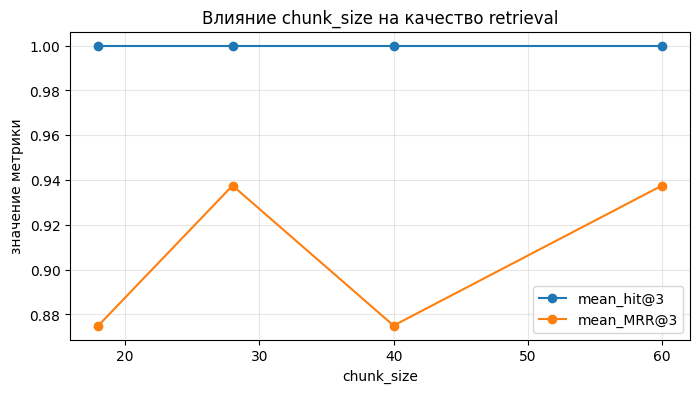

In [17]:


# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [18]:
new_documents: List[Dict[str, str]] = [
    {
          "doc_id": "sql_12",
          "title": "Представления (VIEW)",
          "text": (
              "Представление (VIEW) — это виртуальная таблица, которая создаётся на основе результата SELECT-запроса. "
              "Она не хранит данные самостоятельно, а лишь сохраняет запрос. Преимущества: упрощение сложных запросов, "
              "повышение безопасности (можно скрыть реальные столбцы таблицы), абстракция от изменений в схемах. "
              "Синтаксис: CREATE VIEW view_name AS SELECT ... Изменяемые представления (с определёнными ограничениями) "
              "поддерживают INSERT, UPDATE и DELETE."
          ),
    },
    {
          "doc_id": "sql_13",
          "title": "Хранимые процедуры и функции",
          "text": (
              "Хранимые процедуры — это набор SQL-инструкций, который сохраняется на сервере БД и может выполняться многократно. "
              "Они принимают параметры, могут содержать условную логику (IF, CASE) и циклы. Отличие от функций: "
              "функция обязательно возвращает значение и может использоваться внутри SELECT, процедура может не возвращать ничего "
              "и больше подходит для сложных операций. Плюсы: уменьшение сетевого трафика, централизация бизнес-логики, "
              "повышение безопасности. Минусы: усложнение отладки и переноса между разными СУБД."
          ),
    },
]

In [19]:
updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [

    "Что такое представление VIEW?",
    "Зачем нужны хранимые процедуры?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,sql_12,Представления (VIEW)
1,sql_13,Хранимые процедуры и функции


### Как baseline-база отвечает на новые запросы

**Запрос:** Что такое представление VIEW?

,rank,score,doc_id,title,chunk_text
0,1,0.203819,sql_06,Объединение таблиц JOIN,INNER JOIN и LEFT JOIN для анализа связанных д...
1,2,0.196872,sql_06,Объединение таблиц JOIN,JOIN — все записи из левой таблицы и совпадающ...
2,3,0.192639,sql_01,Что такое реляционная база данных,Реляционная база данных хранит информацию в св...


**Запрос:** Зачем нужны хранимые процедуры?

,rank,score,doc_id,title,chunk_text
0,1,0.358064,sql_10,Нормализация баз данных,Нормализация — процесс организации данных для ...
1,2,0.343756,sql_09,Транзакции и ACID,"данных после транзакции), Изоляция (параллельн..."
2,3,0.328201,sql_10,Нормализация баз данных,— нет частичных зависимостей от составного клю...


In [20]:
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
        {
        "query_id": "q09",
        "query": "Что такое представление VIEW?",
        "relevant_doc_ids": ["sql_12"],
    },
    {
        "query_id": "q10",
        "query": "Зачем нужны хранимые процедуры?",
        "relevant_doc_ids": ["sql_13"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое подзапрос?,sql_07,"sql_07, sql_09, sql_03",1,1.0,1.0,1.0,"sql_07, sql_09, sql_12",1,1.0,1.0,1
1,q02,что делает ORDER BY?,sql_03,"sql_03, sql_11, sql_07",1,1.0,1.0,1.0,"sql_03, sql_11, sql_13",1,1.0,1.0,1
2,q03,Что такое нормализация баз данных?,sql_10,"sql_01, sql_10",1,1.0,0.5,2.0,"sql_01, sql_10",1,1.0,0.5,2
3,q04,Для чего нужен JOIN?,sql_06,sql_06,1,1.0,1.0,1.0,sql_06,1,1.0,1.0,1
4,q05,Что такое индекс в базе данных?,sql_08,"sql_08, sql_01",1,1.0,1.0,1.0,"sql_08, sql_01",1,1.0,1.0,1
5,q06,Зачем нужны транзакции?,sql_09,"sql_09, sql_01",1,1.0,1.0,1.0,"sql_09, sql_13",1,1.0,1.0,1
6,q07,Что делает GROUP BY?,sql_05,"sql_05, sql_06",1,1.0,1.0,1.0,"sql_05, sql_06",1,1.0,1.0,1
7,q08,Что такое оконные функции?,sql_11,"sql_11, sql_04",1,1.0,1.0,1.0,"sql_11, sql_04, sql_12",1,1.0,1.0,1
8,q09,Что такое представление VIEW?,sql_12,"sql_06, sql_01",0,0.0,0.0,NaN,sql_12,1,1.0,1.0,1
9,q10,Зачем нужны хранимые процедуры?,sql_13,"sql_10, sql_09",0,0.0,0.0,NaN,sql_13,1,1.0,1.0,1


,metric,before_update,after_update,delta
0,mean_hit@3,0.80,1.00,0.2
1,mean_recall@3,0.80,1.00,0.2
2,mean_MRR@3,0.75,0.95,0.2


### Как updated-база отвечает на новые запросы

**Запрос:** Что такое представление VIEW?

,rank,score,doc_id,title,chunk_text
0,1,0.547353,sql_12,Представления (VIEW),Представление (VIEW) — это виртуальная таблица...
1,2,0.504973,sql_12,Представления (VIEW),запрос. Преимущества: упрощение сложных запрос...
2,3,0.301147,sql_12,Представления (VIEW),view_name AS SELECT ... Изменяемые представлен...


**Запрос:** Зачем нужны хранимые процедуры?

,rank,score,doc_id,title,chunk_text
0,1,0.453888,sql_13,Хранимые процедуры и функции,"Хранимые процедуры — это набор SQL-инструкций,..."
1,2,0.451293,sql_13,Хранимые процедуры и функции,"условную логику (IF, CASE) и циклы. Отличие от..."
2,3,0.422023,sql_13,Хранимые процедуры и функции,не возвращать ничего и больше подходит для сло...


In [21]:
# Посмотрим, по каким запросам retrieval всё ещё может ошибаться.
analysis_rows = []

for row in extended_benchmark_queries:
    metrics = evaluate_query(
        query=row["query"],
        relevant_doc_ids=row["relevant_doc_ids"],
        artifacts=updated_artifacts,
        top_k=3,
    )
    analysis_rows.append(
        {
            "query_id": row["query_id"],
            "query": row["query"],
            "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            "hit@3": metrics["hit"],
            "first_relevant_rank": metrics["first_relevant_rank"],
        }
    )

analysis_df = pd.DataFrame(analysis_rows)
failed_or_weak = analysis_df[
    (analysis_df["hit@3"] == 0) | (analysis_df["first_relevant_rank"].fillna(99) > 1)
].reset_index(drop=True)

display(failed_or_weak if len(failed_or_weak) > 0 else analysis_df.head(0))

if len(failed_or_weak) == 0:
    print("На этом маленьком benchmark все запросы нашли релевантный документ на первом месте.")
else:
    print("Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,first_relevant_rank
0,q03,Что такое нормализация баз данных?,sql_10,"sql_01, sql_10",1,2


Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.


## mini-Rag

In [22]:
# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

NumPy: 2.2.4
Pandas: 2.2.3
FAISS доступен: True
sentence-transformers доступен: True


In [23]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

In [24]:


artifacts = build_retriever(
    documents,
    chunk_size=24,
    overlap=6,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 28


,doc_id,title,chunk_id,chunk_text
0,sql_01,Что такое реляционная база данных,sql_01_chunk_01,Реляционная база данных хранит информацию в св...
1,sql_01,Что такое реляционная база данных,sql_01_chunk_02,определённым типом данных). Связи между таблиц...
2,sql_02,SELECT и фильтрация данных,sql_02_chunk_01,Оператор SELECT используется для выборки данны...
3,sql_02,SELECT и фильтрация данных,sql_02_chunk_02,"применяется WHERE с условиями: =, <>, >, <, LI..."
4,sql_03,Сортировка и ограничение результатов,sql_03_chunk_01,ORDER BY сортирует результаты запроса по одном...


In [25]:


sample_queries = [
    "Что такое представление VIEW?",
    "Зачем нужны хранимые процедуры?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3))



### Запрос: Что такое представление VIEW?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.333983,sql_08,Индексы и производительность,sql_08_chunk_03,"столбцы, по которым реально часто ищут или фил..."
1,2,0.224397,sql_08,Индексы и производительность,sql_08_chunk_01,"Индекс — это структура данных, ускоряющая поис..."
2,3,0.210604,sql_01,Что такое реляционная база данных,sql_01_chunk_01,Реляционная база данных хранит информацию в св...


### Запрос: Зачем нужны хранимые процедуры?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.363896,sql_10,Нормализация баз данных,sql_10_chunk_01,Нормализация — процесс организации данных для ...
1,2,0.352338,sql_09,Транзакции и ACID,sql_09_chunk_02,Согласованность (целостность данных после тран...
2,3,0.332445,sql_10,Нормализация баз данных,sql_10_chunk_03,"на 3НФ, но в аналитических системах допустима ..."


In [26]:


# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer


def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

baseline_example = answer_without_retrieval(
        "Что такое реляционная база данных и как в ней связаны таблицы?",
    documents,
)

display(pd.DataFrame([baseline_example]))



,answer,selected_doc_id,selected_title,score
0,Реляционная база данных хранит информацию в св...,sql_01,Что такое реляционная база данных,0.306142


In [27]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

query = "Зачем нужна нормализация?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)



### Запрос: Зачем нужна нормализация?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.493924,sql_10,Нормализация баз данных,sql_10_chunk_01,Нормализация — процесс организации данных для ...
1,2,0.300861,sql_10,Нормализация баз данных,sql_10_chunk_03,"на 3НФ, но в аналитических системах допустима ..."
2,3,0.212438,sql_10,Нормализация баз данных,sql_10_chunk_02,"столбцах, 2НФ — нет частичных зависимостей от ..."


[Источник: sql_10 | Нормализация баз данных | score=0.4939]
Нормализация — процесс организации данных для устранения избыточности и аномалий. Основные нормальные формы: 1НФ — атомарные значения в столбцах, 2НФ — нет частичных зависимостей

[Источник: sql_10 | Нормализация баз данных | score=0.3009]
на 3НФ, но в аналитических системах допустима денормализация для ускорения чтения.

[Источник: sql_10 | Нормализация баз данных | score=0.2124]
столбцах, 2НФ — нет частичных зависимостей от составного ключа, 3НФ — нет транзитивных зависимостей. На практике часто останавливаются на 3НФ, но в аналитических системах


In [28]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [29]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [30]:
rag_result = mini_rag_answer(
    "Что такое индекс в базе данных?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Что такое индекс в базе данных?

**Ответ:** Индекс — это структура данных, ускоряющая поиск строк по определённым столбцам. Создаётся индекс командой CREATE INDEX idx_name ON table_name(column).

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.750369,sql_08,Индексы и производительность,sql_08_chunk_01,"Индекс — это структура данных, ускоряющая поис..."
1,2,0.665609,sql_01,Что такое реляционная база данных,sql_01_chunk_01,Реляционная база данных хранит информацию в св...
2,3,0.569244,sql_01,Что такое реляционная база данных,sql_01_chunk_02,определённым типом данных). Связи между таблиц...


In [31]:
# Сохранение retrieval_eval.csv
baseline_eval_k3.to_csv("artifacts/retrieval_eval.csv", index=False)

# Сохранение retrieval_before_after_update.csv
comparison_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)

# Сохранение rag_examples.csv (нужно собрать несколько примеров)
rag_examples_list = []
test_queries = ["Что такое индекс в базе данных?", "Что такое подзапрос?", "Что делает GROUP BY?"]
for q in test_queries:
    res = mini_rag_answer(q, artifacts=artifacts, top_k=3)
    rag_examples_list.append({
        "question": res["query"],
        "answer": res["answer"],
        "retrieved_sources": ", ".join(res["sources"]["doc_id"].tolist())
    })
rag_examples_df = pd.DataFrame(rag_examples_list)
rag_examples_df.to_csv("artifacts/rag_examples.csv", index=False)